In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/clothes_price_prediction_data.csv')

In [3]:
colunas = {
    'Brand': 'Marca',
    'Category': 'Categoria',
    'Color': 'Cor',
    'Size': 'Tamanho',
    'Price': 'Preco'
}

df = df.rename(columns=colunas)
df.head(10)

,Marca,Categoria,Cor,Tamanho,Material,Preco
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113
5,Reebok,Jacket,Red,XL,Nylon,19
6,Puma,Jacket,Red,XXL,Polyester,31
7,Adidas,Dress,Red,XS,Denim,46
8,Reebok,Dress,Black,S,Wool,97
9,Adidas,Jeans,Yellow,L,Wool,80


In [4]:
maior = df['Preco'].max()

menor = df['Preco'].min()

print("Maior:", maior)
print("Menor:", menor)

Maior: 199
Menor: 10


In [5]:
media = df['Preco'].mean()

mediana = df['Preco'].median()

moda = df['Preco'].mode()[0]

print("Média:",media)
print("Mediana:",mediana)
print("Moda:",moda)

Média: 106.289
Mediana: 108.0
Moda: 97


In [6]:
df.isnull().sum()

Marca        0
Categoria    0
Cor          0
Tamanho      0
Material     0
Preco        0
dtype: int64

In [22]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(df[['Marca', 'Categoria', 'Cor', 'Tamanho', 'Material']])

encoded_df = df

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Marca', 'Categoria', 'Cor', 'Tamanho', 'Material']))

encoded_df['Preco'] = df['Preco']

encoded_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Marca_Adidas        1000 non-null   float64
 1   Marca_New Balance   1000 non-null   float64
 2   Marca_Nike          1000 non-null   float64
 3   Marca_Puma          1000 non-null   float64
 4   Marca_Reebok        1000 non-null   float64
 5   Marca_Under Armour  1000 non-null   float64
 6   Categoria_Dress     1000 non-null   float64
 7   Categoria_Jacket    1000 non-null   float64
 8   Categoria_Jeans     1000 non-null   float64
 9   Categoria_Shoes     1000 non-null   float64
 10  Categoria_Sweater   1000 non-null   float64
 11  Categoria_T-shirt   1000 non-null   float64
 12  Cor_Black           1000 non-null   float64
 13  Cor_Blue            1000 non-null   float64
 14  Cor_Green           1000 non-null   float64
 15  Cor_Red             1000 non-null   float64
 16  Cor_White         

In [28]:
Y = encoded_df['Preco']

X = encoded_df.drop(columns=['Preco'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
modelo_arvore1 = RandomForestRegressor(random_state=42)

modelo_arvore1.fit(X_train, Y_train)

previsoes_arvore1 = modelo_arvore1.predict(X_test)

In [10]:
erro_arvore1 = mean_absolute_error(Y_test, previsoes_arvore1)

erro_arvore1

47.551770873015876

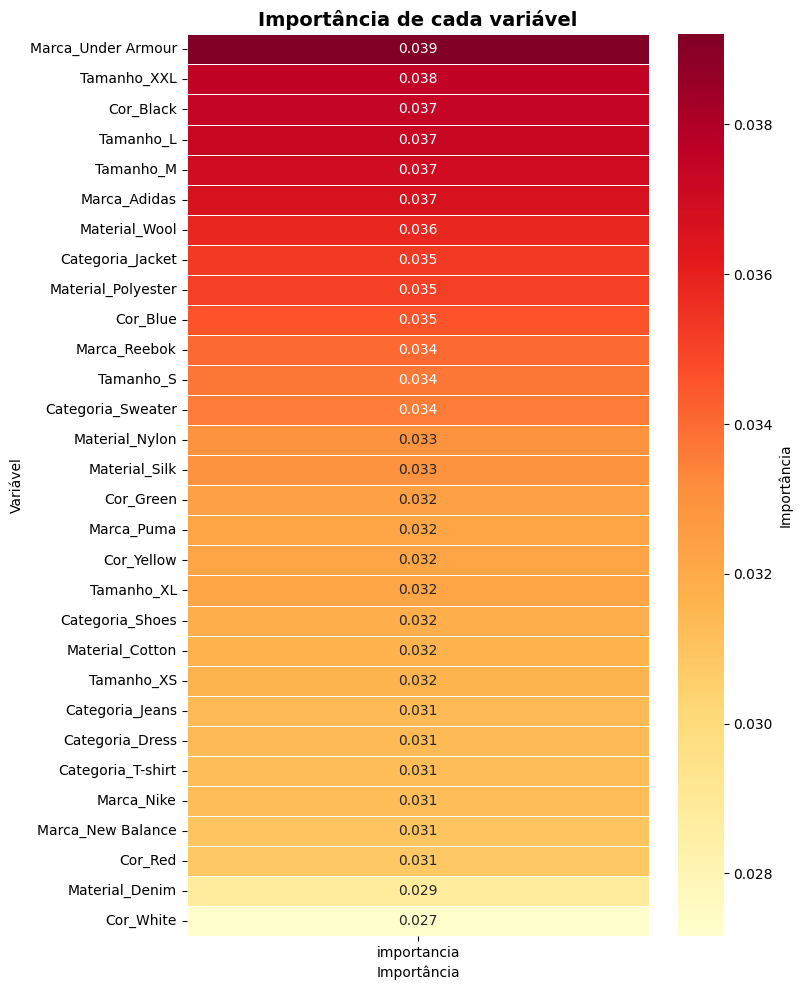

In [34]:
importances1 = modelo_arvore1.feature_importances_

df_importancia1 = pd.DataFrame({
    "variavel": X_train.columns,
    "importancia": importances1
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(8, 10))

sns.heatmap(
    df_importancia1.set_index("variavel"), 
    annot=True,
    fmt=".3f",  
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Importância"}
)

plt.title("Importância de cada variável", fontsize=14, fontweight="bold")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

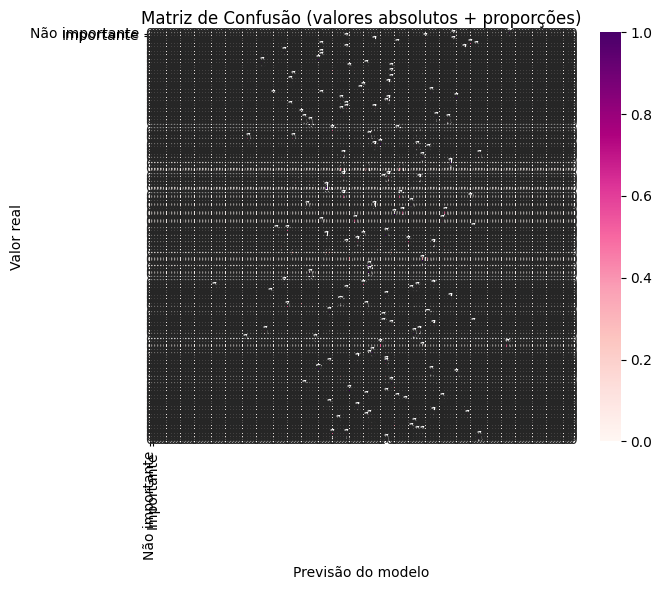

Acurácia: 0.005


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

Y_test = Y_test.astype('int64')
previsoes_arvore1 = previsoes_arvore1.astype('int64')

if len(Y_test) != len(previsoes_arvore1):
    raise ValueError("Y_test e previsoes_arvore1 têm tamanhos diferentes!")

matriz = confusion_matrix(Y_test, previsoes_arvore1)

matriz_norm = matriz.astype('float') / matriz.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    matriz_norm,
    annot=matriz,       
    fmt='d',
    cmap='RdPu',
    xticklabels=['Não importante','Importante'],
    yticklabels=['Não importante','Importante'],
    cbar=True
)

plt.title("Matriz de Confusão (valores absolutos + proporções)")
plt.xlabel("Previsão do modelo")
plt.ylabel("Valor real")

plt.tight_layout()
plt.show()

print("Acurácia:", accuracy_score(Y_test, previsoes_arvore1))